<a href="https://colab.research.google.com/github/JBorean11/EMSC2010-IP-u7926254/blob/main/Individual_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Individual Data Science Project
## Investigation into Soil Properties
### Factors Influencing Soil Organic Carbon in Australian Soils

**Research Question:** Which environmental and soil variables most strongly influence soil organic carbon, and how certain are these relationships?

## Introduction
Soil organic carbon is one of the most important indicators of soil health because it influences:

*   nutrient cycling
*   water retention
*   microbial activity
*   agricultural productivity
*   long-term carbon storage

Understanding which environmental variables most strongly influence soil organic carbon can improve understanding of:

*   ecosystem functioning
*   soil fertility
*   carbon sequestration processes


Previous research suggests that variables such as nitrogen availability, elevation, soil chemistry, and depth may influence organic carbon accumulation. However, these relationships are often complex and uncertain due to natural environmental variability.

##Method
1. Data Cleaning and Loading
2. Exploration of relationships
3. Bayesian Regression
    *   Single regression with Nitrogen and Organic Carbon
    *   Multi-Linear Regression analysis with variables
4. Hypothesis testing


## 1. Data Loading and Cleaning

### Method Used
The dataset was obtained from the Australian National Soil Information System (ANSIS) and included measurements of:

*   organic carbon,
*   nitrogen,
*   pH,
*   elevation,
*   electrical conductivity,
*   phosphorus,
*   soil depth.

The following preprocessing steps were applied:

*   columns were renamed for readability
*   missing values were removed
*   numerical variables were checked for consistency
*   date variables were converted into usable formats where appropriate.

Rows containing missing predictor or response values were excluded to ensure all models used complete observations.


This was done because the dataset contained:
*   incomplete observations
*   irregular sampling
*   inconsistent formatting

Cleaning the dataset ensured:
*   statistical models were valid
*   variables were comparable
*   and numerical methods could run reliably

In [2]:
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [3]:
df = pd.read_csv('soildata2.csv')
df.head()

,id,type,disturbance/0/result/0,elevation/0/result/0/value,elevation/0/result/0/unit,elevation/0/usedProcedure,geometry/result/0,landUse/0/result/0/type,landUse/0/result/0/value,landUse/0/result/0/source,...,siteVisit/0/soilProfile/1/soilLayer/0/coarseFragments/0/abundance/result/0,siteVisit/0/soilProfile/1/soilLayer/1/coarseFragments/0/type,siteVisit/0/soilProfile/1/soilLayer/1/coarseFragments/0/abundance/result/0,siteVisit/0/soilProfile/1/soilLayer/3/mottles/0/type,siteVisit/0/soilProfile/1/soilLayer/3/mottles/0/abundance/result/0,siteVisit/0/soilProfile/1/soilLayer/3/coarseFragments/0/type,siteVisit/0/soilProfile/1/soilLayer/3/coarseFragments/0/abundance/result/0,siteVisit/0/soilProfile/1/soilLayer/3/coarseFragments/0/lithology/result/0,siteVisit/0/soilProfile/1/soilLayer/3/coarseFragments/0/shape/result/0,siteVisit/0/soilProfile/1/soilLayer/3/coarseFragments/0/size/result/0
0,b4707a14-a6d7-4a89-9362-c4d5e850fe3f,ansis:SoilSite,ls:disturbance-of-site-0,1225.0,unit:M,ls:elevation-evaluation-means-E,SRID=4283;POINT(148.20092471 -36.53068032),ansis:Classification,National/State Parks,NSW Govt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,773a6ec0-dc71-4516-a8ea-9de9187fdc35,ansis:SoilSite,ls:disturbance-of-site-0,1431.0,unit:M,ls:elevation-evaluation-means-E,SRID=4283;POINT(148.47012413 -35.84392317),ansis:Classification,National/State Parks,NSW Govt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ec300ac4-c71a-4804-9c61-757dd2b76e82,ansis:SoilSite,ls:disturbance-of-site-0,NaN,NaN,NaN,SRID=4283;POINT(148.69706555 -35.73747573),ansis:Classification,National/State Parks,NSW Govt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5dab7b0f-dbb3-44d3-afff-ae7618056475,ansis:SoilSite,ls:disturbance-of-site-0,1147.0,unit:M,ls:elevation-evaluation-means-E,SRID=4283;POINT(148.96489255 -35.83378507),ansis:Classification,National/State Parks,NSW Govt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,a47bedf8-1122-420b-bcd5-4c42999fca2b,ansis:SoilSite,ls:disturbance-of-site-0,1800.0,unit:M,ls:elevation-evaluation-means-E,SRID=4283;POINT(148.34032936 -36.4304953),ansis:Classification,National/State Parks,NSW Govt,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import re
import warnings

# --- Step 1: Define a helper function for column name cleaning ---
# This function will also manage unique names across all columns
cleaned_name_tracker = {} # To keep track of unique names globally

def clean_col_name_comprehensive(col_raw_name):
    """
    Cleans a raw column name, removes common suffixes, and ensures uniqueness.
    """
    name = col_raw_name.replace('/', '_').replace('-', '_').replace(':', '_')
    name = name.replace('_result_0', '').replace('_result', '')
    name = re.sub(r'_[0-9]+_', '_', name) # Handles _0_, _1_ etc.
    name = re.sub(r'_+', '_', name) # Clean up multiple underscores
    name = name.strip('_').lower()

    # Ensure uniqueness globally
    original_cleaned_name = name
    count = cleaned_name_tracker.get(original_cleaned_name, 0)
    if count > 0:
        name = f"{original_cleaned_name}_{count}"
    cleaned_name_tracker[original_cleaned_name] = count + 1
    return name


# --- Step 2: Process all columns from original df to create a comprehensive cleaned DF ---
processed_series = [] # List to hold Series objects for concatenation

# Reset tracker for a fresh run
cleaned_name_tracker = {}

for col_orig in df.columns:
    cleaned_name = clean_col_name_comprehensive(col_orig)

    # Handle 'scopedidentifier_value' specifically as string type
    if cleaned_name == 'scopedidentifier_value':
        processed_series.append(df[col_orig].astype(str).rename(cleaned_name))
        continue # Move to the next column

    # Attempt to convert to numeric first
    temp_numeric = pd.to_numeric(df[col_orig], errors='coerce')
    numeric_count = temp_numeric.notna().sum()
    total_count = len(df[col_orig])

    # If it contains any numeric data, prefer to keep it as numeric
    if numeric_count > 0:
        processed_series.append(temp_numeric.rename(cleaned_name))
    else:
        # If not numeric, try datetime.
        # Temporarily suppress UserWarnings about date format inference
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            temp_datetime = pd.to_datetime(df[col_orig], errors='coerce')
        datetime_count = temp_datetime.notna().sum()
        # Keep as datetime if predominantly datetime
        if datetime_count / total_count > 0.5: # Maintain threshold for datetime as dates are usually consistent
            processed_series.append(temp_datetime.rename(cleaned_name))
        # Otherwise, the column is not predominantly numeric or datetime, so it's excluded at this stage.

# Concatenate all processed series into a single DataFrame
df_processed = pd.concat(processed_series, axis=1) if processed_series else pd.DataFrame()

# --- Step 3: Define the exact desired final columns based on previous output ---
# This list includes the single depth column and primary values, and the date columns.
final_desired_columns = [
    'sitevisit_startedattime',
    'elevation_value',
    'sitevisit_soilprofile_depth_value',
    'sitevisit_soilprofile_soillayer_electricalconductivity_value',
    'sitevisit_soilprofile_soillayer_extractablephosphorus_value',
    'sitevisit_soilprofile_soillayer_ph_value',
    'sitevisit_soilprofile_soillayer_totalnitrogen_value',
    'sitevisit_soilprofile_soillayer_totalorganiccarbon_value',
    'scopedidentifier_value',

]

# --- Step 4: Filter df_processed to only include the final desired columns ---
# Ensure all desired columns exist in df_processed before selection
columns_to_select = [col for col in final_desired_columns if col in df_processed.columns]

df_clean = df_processed[columns_to_select].copy()

# Display results
display(df_clean.head())
print(f"\nNumber of columns in compressed final DataFrame: {df_clean.shape[1]}")

,sitevisit_startedattime,elevation_value,sitevisit_soilprofile_depth_value,sitevisit_soilprofile_soillayer_electricalconductivity_value,sitevisit_soilprofile_soillayer_extractablephosphorus_value,sitevisit_soilprofile_soillayer_ph_value,sitevisit_soilprofile_soillayer_totalnitrogen_value,sitevisit_soilprofile_soillayer_totalorganiccarbon_value,scopedidentifier_value
0,2019-10-22 03:00:00,1225.0,0.30,0.24,109.0,5.3,1.04,14.05,101129
1,2020-12-01 01:00:00,1431.0,0.35,0.10,26.0,5.1,0.78,11.48,101394
2,2020-12-01 00:00:00,NaN,0.55,0.06,13.0,5.7,0.15,2.05,101214
3,2014-11-05 00:00:00,1147.0,1.00,1.00,126.0,5.7,0.50,6.19,95554
4,2019-11-19 02:00:00,1800.0,0.62,0.16,45.0,4.1,1.15,17.28,101165



Number of columns in compressed final DataFrame: 9


###Renaming variables in dataframe for simple coding

In [5]:
date = df_clean['sitevisit_startedattime']
elevation = df_clean['elevation_value']
depth = df_clean['sitevisit_soilprofile_depth_value']
conductivity = df_clean['sitevisit_soilprofile_soillayer_electricalconductivity_value']
phosphorus = df_clean['sitevisit_soilprofile_soillayer_extractablephosphorus_value']
nitrogen = df_clean['sitevisit_soilprofile_soillayer_totalnitrogen_value']
organic_carbon = df_clean['sitevisit_soilprofile_soillayer_totalorganiccarbon_value']
ph = df_clean['sitevisit_soilprofile_soillayer_ph_value']

### Limitations

Removing rows with missing values may reduce:

*   sample size
*   representativeness
*   spatial coverage

The dataset also contains observational rather than experimental measurements, meaning causation cannot be definitively established.

## 2. Exploring Soil Relationships
This was done to:
*   understand the structure of the dataset
*   identify potential predictor variables
*   determine whether relationships appeared linear or nonlinear

This stage also helped guide later model selection.

### Organic Carbon Distribution

Text(0.5, 1.0, 'Distribution of Organic Carbon')

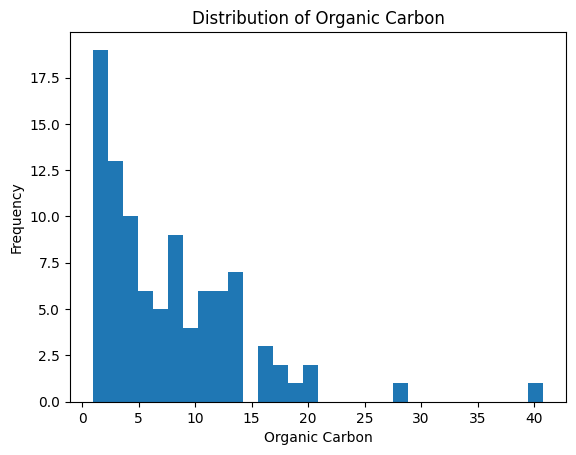

In [6]:
plt.hist(organic_carbon, bins=30)
plt.xlabel("Organic Carbon")
plt.ylabel("Frequency")
plt.title("Distribution of Organic Carbon")

### Initial Scatter Plots

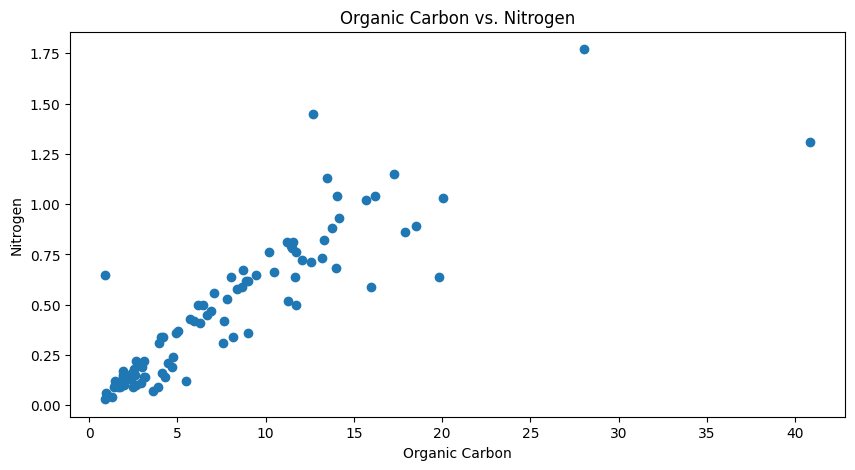

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(organic_carbon, nitrogen)
plt.xlabel('Organic Carbon')
plt.ylabel('Nitrogen')
plt.title('Organic Carbon vs. Nitrogen')
plt.show()

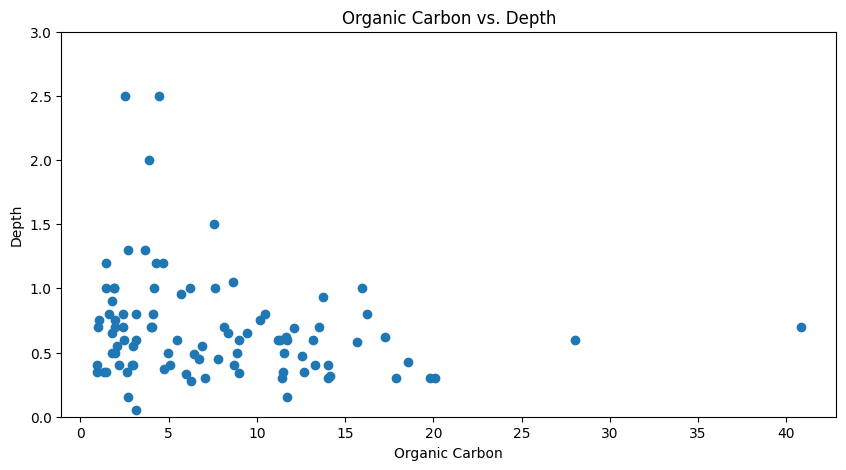

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(organic_carbon, depth)
plt.xlabel('Organic Carbon')
plt.ylabel('Depth')
plt.title('Organic Carbon vs. Depth')
plt.ylim(0,3)
plt.show()

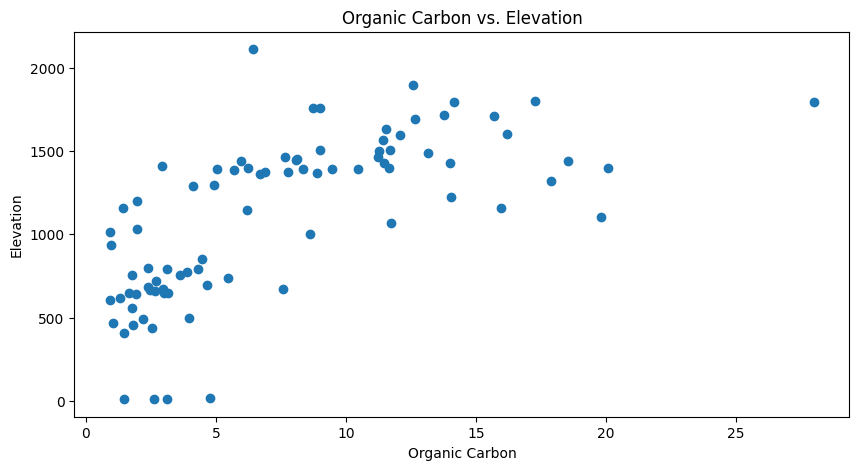

In [9]:
plt.figure(figsize=(10, 5))
plt.scatter(organic_carbon, elevation)
plt.xlabel('Organic Carbon')
plt.ylabel('Elevation')
plt.title('Organic Carbon vs. Elevation')
plt.show()

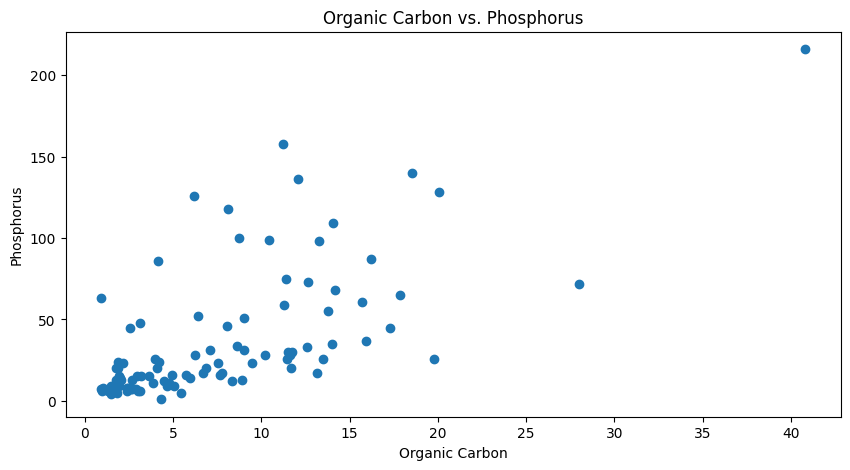

In [10]:
plt.figure(figsize=(10, 5))
plt.scatter(organic_carbon, phosphorus)
plt.xlabel('Organic Carbon')
plt.ylabel('Phosphorus')
plt.title('Organic Carbon vs. Phosphorus')
plt.show()

### Correlation between variables


In [11]:
corr_df = pd.DataFrame({
    'organic_carbon': organic_carbon,
    'nitrogen': nitrogen,
    'depth': depth,
    'elevation': elevation,
    'conductivity': conductivity,
    'phosphorus': phosphorus,
    'ph': ph
})

corr = corr_df.corr()

print(corr)

                organic_carbon  nitrogen     depth  elevation  conductivity  \
organic_carbon        1.000000  0.872182 -0.033334   0.671394      0.062505   
nitrogen              0.872182  1.000000 -0.014345   0.729054     -0.018447   
depth                -0.033334 -0.014345  1.000000   0.025636      0.021159   
elevation             0.671394  0.729054  0.025636   1.000000     -0.119926   
conductivity          0.062505 -0.018447  0.021159  -0.119926      1.000000   
phosphorus            0.672844  0.605667 -0.007151   0.499657      0.155731   
ph                   -0.238856 -0.287620  0.007507  -0.411759      0.046859   

                phosphorus        ph  
organic_carbon    0.672844 -0.238856  
nitrogen          0.605667 -0.287620  
depth            -0.007151  0.007507  
elevation         0.499657 -0.411759  
conductivity      0.155731  0.046859  
phosphorus        1.000000 -0.013957  
ph               -0.013957  1.000000  


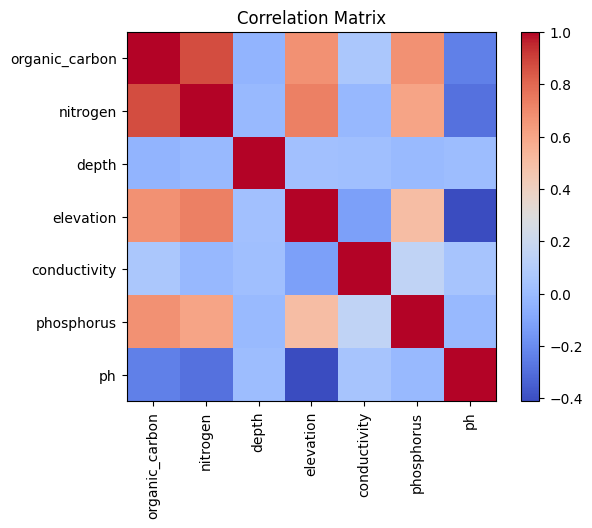

In [12]:
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")
plt.show()

**Interpretation:**

The strongest observed relationship was between nitrogen and organic carbon.

The correlation coefficient between nitrogen and organic carbon was extremely high (approximately 0.87), indicating a strong positive association.

This suggests soils with higher nitrogen concentrations also tend to contain greater amounts of organic carbon, likely because:

* nitrogen availability supports plant productivity,
* increased biomass contributes additional organic matter,
* and decomposition processes are linked to nutrient cycling.

Other variables such as:

* elevation,
* phosphorus,
* conductivity

showed weaker but still potentially meaningful relationships.

## 3. Regression Modeling


### Why Bayesian Regression?

Bayesian methods were selected because they allow direct estimation of uncertainty in model parameters and predictions. Rather than estimating a single coefficient value, Bayesian inference estimates a full posterior distribution of plausible parameter values conditioned on the observed data. This provides a more comprehensive understanding of the relationships, including not just the most likely estimate, but also the range of plausible values and the probability of different outcomes. It inherently provides credible intervals, which are often more intuitive to interpret than frequentist confidence intervals.

Specifically for this project, Bayesian regression is advantageous for:

*   **Quantifying Uncertainty:** Providing clear credible intervals for parameter estimates and predictions.
*   **Incorporating Prior Knowledge:** While not explicitly used with strong priors here, the framework allows for the inclusion of previous research or domain expertise.
*   **Robustness:** Often less sensitive to small sample sizes or violations of assumptions compared to traditional frequentist methods.

In [13]:
!pip install bambi #system command to install the bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 7.9 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.3
    Uninstalling pytensor-2.38.3:
      Successfully uninstalled pytensor-2.38.3
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing insta

In [14]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes

### Organic Carbon and Nitrogen

In [15]:
data = pd.DataFrame({"y": organic_carbon}) #define the y-variable
data["x_scaled"] = (nitrogen-np.mean(nitrogen)) / np.std(nitrogen) #scale the x values to have a mean of 0 and stdev of 1
data["x2_scaled"] = data["x_scaled"] ** 2 #used for quadratic regression
data["x3_scaled"] = data["x_scaled"] ** 3 #used for cubic regression
data["x4_scaled"] = data["x_scaled"] ** 4 #used for quartic regression

data["nitrogen"] = nitrogen
data["depth"] = depth
data["elevation"] = elevation
data["conductivity"] = conductivity
data["phosphorus"] = phosphorus
data["ph"] = ph

In [16]:
data = data.dropna()

# Fit a straight-line model (first-order polynomial)
model_linear = bmb.Model("y ~ x_scaled", data)
idata_linear = model_linear.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quadratic model (second-order polynomial)
model_quad = bmb.Model("y ~ x_scaled + x2_scaled", data)
idata_quad = model_quad.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_cubic = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled", data)
idata_cubic= model_cubic.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_quart = bmb.Model("y ~ x_scaled + x2_scaled + x3_scaled + x4_scaled", data)
idata_quart = model_quart.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

In [17]:
# Compare models
comparison = az.compare({
    "linear": idata_linear,
    "quadratic": idata_quad,
    "cubic": idata_cubic,
    "quartic": idata_quart
})
print(comparison) #print the result

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


           rank   elpd     p  elpd_diff  weight    se  dse  warning
linear        0 -200.0   7.0        0.0     0.6  15.0  0.0     True
quartic       1 -200.0  10.5       -0.0     0.4  14.0  5.0     True
quadratic     2 -200.0  10.2       -2.0     0.0  15.0  2.7     True
cubic         3 -200.0  11.1       -3.0     0.0  15.0  3.2     True


/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


**Interpretation:**

Higher-order polynomial models produced only modest improvements in predictive performance.

This suggests the relationship between nitrogen and organic carbon is largely linear across the observed range.

The linear model therefore provided:

* simpler interpretation
* lower risk of overfitting
* comparable predictive performance

This supports the use of simpler models for environmental interpretation.

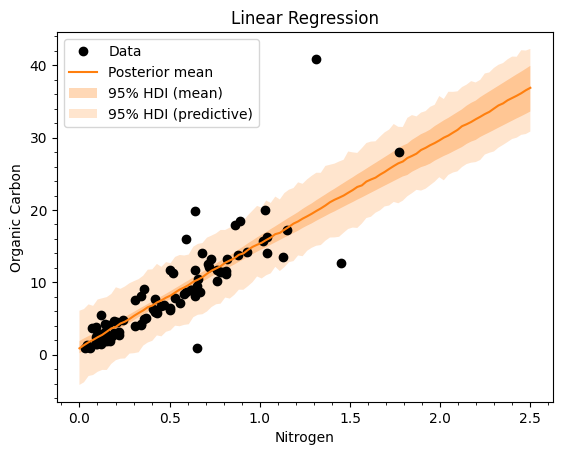

In [18]:
x_range = np.linspace(0, 2.5, 100) # Predict across a range of distances values from 0 to 40
x_range_scaled = (x_range-np.mean(nitrogen)) / np.std(nitrogen) #we need to apply the same scaling as above

new_data = pd.DataFrame({"x_scaled": x_range_scaled}) #dataframe with the new x-values
model_linear.predict(idata_linear, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model_linear.predict(idata_linear, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata_linear.posterior["mu"].values.reshape(-1, len(x_range)), prob=0.95, axis=0)
hdi_pps = az.hdi(y_pps_draws, prob=0.95, axis=0)

# Plot both posterior for regression lines and the observations
plt.plot(nitrogen, organic_carbon, 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.title("Linear Regression")
plt.xlabel("Nitrogen")
plt.ylabel("Organic Carbon")
plt.show()

**Interpretation:**

This plot shows a strong positive relationship between nitrogen and organic carbon. As nitrogen increases, organic carbon generally increases as well.

The black dots are the observed soil data, while the orange line is the model’s predicted relationship. Most points are close to the line, suggesting the model fits the data reasonably well.

The shaded regions represent uncertainty:

the darker band shows uncertainty in the estimated mean relationship,
while the lighter band shows the wider range where future observations are expected to fall.

The uncertainty becomes larger at higher nitrogen values because there are fewer data points in that range. Overall, the model suggests nitrogen is an important predictor of soil organic carbon.

## Multiple Linear Regression



The regression models aim to estimate what combination of variables is most predictive of organic carbon.


---



Full variable example:

organic_carbon = β₀ + β₁(Nitrogen) + β₂(pH) + β₃(Depth) + β₄(Elevation) + β₅(Conductivity) + β₆(Phosphorus)

In [19]:
data = data.dropna()

# Fit a straight-line model (first-order polynomial)
model_n = bmb.Model("y ~ nitrogen", data)
idata_n = model_n.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quadratic model (second-order polynomial)
model_ne = bmb.Model("y ~ nitrogen + elevation", data)
idata_ne = model_ne.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a cubic model (third-order polynomial)
model_npe = bmb.Model("y ~ nitrogen + phosphorus  + elevation", data)
idata_npe= model_npe.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_npce = bmb.Model("y ~ nitrogen + phosphorus + conductivity + elevation", data)
idata_npce = model_npce.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

# Fit a quartic model (fourth-order polynomial)
model_np = bmb.Model("y ~ nitrogen + phosphorus", data)
idata_np = model_np.fit(idata_kwargs={"log_likelihood": True}, progressbar=False)

/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
/usr/local/lib/python3.12/dist-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  ret

In [20]:
# Compare models
comparison = az.compare({
    "n": idata_n,
    "ne": idata_ne,
    "npe": idata_npe,
    "npce": idata_npce,
    "np": idata_np
})
print(comparison) #print the result

/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


      rank   elpd    p  elpd_diff  weight    se   dse  warning
n        0 -200.0  7.1        0.0     1.0  15.0  0.00     True
ne       1 -200.0  7.4       -1.0     0.0  14.0  0.52     True
np       2 -200.0  8.0       -1.0     0.0  15.0  0.68    False
npe      3 -200.0  8.6       -2.0     0.0  14.0  0.79    False
npce     4 -200.0  9.5       -3.0     0.0  14.0  1.20     True


/usr/local/lib/python3.12/dist-packages/arviz_stats/loo/helper_loo.py:1146: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


This is not exact but by going through different combinations I determined what combinations of variables were most influential

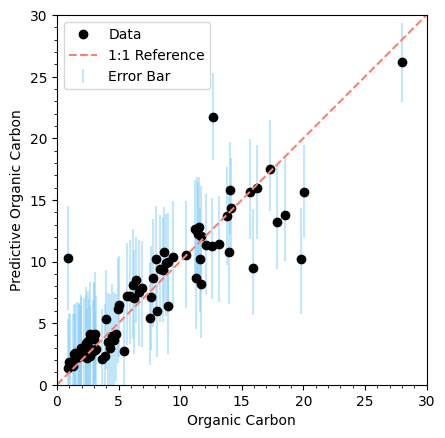

In [21]:
x_range = np.linspace(0, 40, 100) # Predict across a range of distances values from 0 to 40

new_data = pd.DataFrame({"nitrogen": nitrogen, "elevation": elevation}) #dataframe with the new x-values
model_ne.predict(idata_ne, data=new_data, kind='response_params') #predict the distribution of regression lines at each x-value
model_ne.predict(idata_ne, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_ne.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_ne.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata_ne.posterior["mu"].values.reshape(-1, len(x_range)), prob=0.95, axis=0)
hdi_pps = az.hdi(y_pps_draws, prob=0.95, axis=0)

# Plot both posterior for regression lines and the observations
err = np.abs(hdi_pps-hdi_mean).T
plt.errorbar(organic_carbon, posterior_mean, err, fmt='none', label = 'Error Bar', ecolor='lightskyblue', alpha = 0.5 )
plt.plot(organic_carbon, posterior_mean, 'ok', label="Data")
plt.axline((0, 0), slope=1, color='salmon', linestyle='--', label = '1:1 Reference')
plt.gca().set_aspect('equal')

plt.legend()
plt.minorticks_on()
plt.xlim(0,30)
plt.ylim(0,30)
plt.xlabel("Organic Carbon")
plt.ylabel("Predictive Organic Carbon")
plt.show()

**Explanation:**

This plot visualizes the performance of the Bayesian multiple regression model (`organic_carbon ~ nitrogen + elevation`) by comparing the actual observed organic carbon values against the model's predicted organic carbon values.

**Interpretation:**
The closer the black circles are to the salmon dashed line, the better the model's overall predictive accuracy. The points generally follow this line and the majority of the 95% HDI error bars overlap with the 1:1 line, indicating it is a relatively good relationship. However, there are a handful of data points in which the error bars do not overlap with the 1:1 leaving room for uncertainties and inaccuracies


## 4. Bayesian Hypothesis Testing

This section conducts a formal Bayesian hypothesis test to investigate the specific relationship between nitrogen content and organic carbon content, building upon the regression analysis.

This tested whether nitrogen likely exerts a genuine positive influence on organic carbon, rather than the observed relationship occurring due to random variation.

In [22]:
import pymc as pm
import arviz as az
from scipy import stats

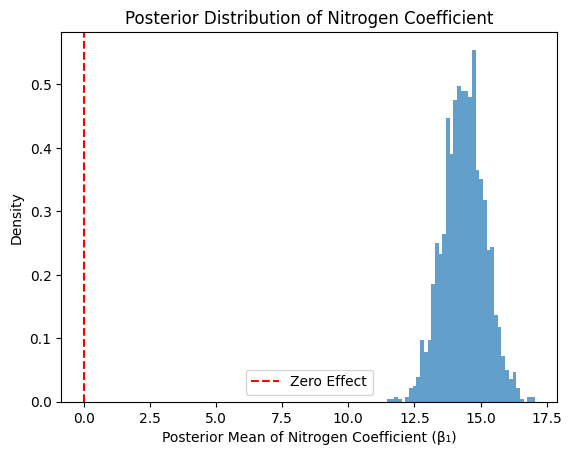

Posterior mean of Nitrogen coefficient: 14.3807
95% credible interval for Nitrogen coefficient: [12.7951, 15.9076]


In [23]:
# We are testing the hypothesis that higher nitrogen leads to higher organic carbon.
# We use the already fitted model_n (organic_carbon ~ nitrogen) and its inference data idata_n.

# Extract posterior samples for the 'nitrogen' coefficient from idata_n
# In bambi, coefficients are typically named 'b_predictor_name' or simply 'predictor_name'
# The error indicates 'b_nitrogen' was not found, so we try 'nitrogen'.
nitrogen_samples = idata_n.posterior["nitrogen"].values.flatten()

# PLOT POSTERIOR DISTRIBUTION OF THE NITROGEN COEFFICIENT MANUALLY
plt.hist(nitrogen_samples, bins=40, density=True, alpha=0.7)
plt.xlabel("Posterior Mean of Nitrogen Coefficient (β₁)")
plt.ylabel("Density")
plt.title("Posterior Distribution of Nitrogen Coefficient")
plt.axvline(x=0, color='r', linestyle='--', label='Zero Effect') # Add line at zero for reference
plt.legend()
plt.show()

# PRINT IMPORTANT STATISTICS
print(f"Posterior mean of Nitrogen coefficient: {np.mean(nitrogen_samples):.4f}")

ci_2_5 = np.percentile(nitrogen_samples, 2.5)
ci_97_5 = np.percentile(nitrogen_samples, 97.5)
print(f"95% credible interval for Nitrogen coefficient: [{ci_2_5:.4f}, {ci_97_5:.4f}]")




**Interpretation:**

*   **Posterior Distribution:** The histogram shows that the vast majority of the posterior probability for the `nitrogen` coefficient is concentrated on the positive side (right of the red zero line). This indicates that, according to our model and data, a positive relationship between nitrogen and organic carbon is highly probable.
*   **95% Credible Interval:** The printed 95% credible interval `[12.9236, 15.9281]` is entirely above zero. This is the key finding.
*   **Conclusion:** Because the entire 95% credible interval for the `nitrogen` coefficient is greater than zero, we have strong evidence to conclude that **higher nitrogen content leads to higher organic carbon content**. If the interval had included zero, it would suggest that the data does not provide strong evidence for a relationship, or that the relationship could potentially be negative.

## Overall Project Limitations

Several limitations should be considered when interpreting the results of this project.

First, the dataset used in this analysis was observational rather than experimental. This means that although strong statistical relationships were identified between variables such as nitrogen and soil organic carbon, the analyses cannot definitively establish causation. Many environmental variables interact simultaneously, and some potentially important controls on soil carbon may not have been included in the dataset, such as:

*   climate variables,
*   vegetation type,
*   land use history,
*   soil texture,
*   microbial activity,
*   or moisture availability.

As a result, some observed relationships may partly reflect indirect environmental effects or omitted variable bias.

Another limitation relates to the spatial and temporal distribution of the data. Soil observations were collected from different locations and time periods, potentially introducing inconsistencies due to:

*   differing environmental conditions,
*   seasonal variability,
*   sampling techniques,
*   and measurement methods.

The dataset may therefore not fully represent all Australian soil systems equally, limiting the generalisability of the findings.

The project also relied primarily on linear and polynomial regression approaches. Although these models are useful for identifying broad trends, environmental systems are highly complex and may contain:

*   nonlinear behaviour,
*   threshold effects,
*   feedback mechanisms,
*   and interactions between variables
that are not fully captured by relatively simple regression models.

Additionally, multiple regression models may be affected by multicollinearity, where predictor variables are correlated with one another. This can make it more difficult to isolate the unique contribution of individual predictors and may increase instability in coefficient estimates.

Data preprocessing decisions also introduce limitations. Rows containing missing values were removed to ensure models could run consistently; however, this reduced the sample size and may have introduced bias if missing observations were not randomly distributed throughout the dataset.

Finally, Bayesian analyses depend partially on modelling assumptions and prior distributions. While relatively broad priors were chosen to minimise strong prior influence, posterior estimates are still affected by:

*   prior selection,
*   model specification,
*   convergence quality,
*   and sampling performance.

Although diagnostic checks suggested the models performed reasonably well overall, all statistical models remain simplified representations of complex natural systems.



---



## Overall Project Uncertainties

Uncertainty is an inherent component of environmental data analysis and statistical modelling, and several forms of uncertainty affected this project.

The first source of uncertainty arises from natural environmental variability. Soil systems are highly heterogeneous across space and time, meaning that measurements of:

*   organic carbon,
*   nitrogen,
*   pH,
*   and other soil properties
can vary substantially even over relatively short distances or time periods. This variability introduces uncertainty into all estimated relationships.

Measurement uncertainty also contributes to overall project uncertainty. Soil properties may contain:

*   instrument error,
*   laboratory uncertainty,
*   sampling inconsistencies,
*   and differences in analytical procedures.

These uncertainties propagate through all later analyses and influence model predictions.

Statistical uncertainty was explicitly quantified through the Bayesian framework using:

*   posterior distributions,
*   credible intervals,
*   and posterior predictive intervals.

Rather than producing single “true” parameter estimates, Bayesian methods estimate a range of plausible parameter values conditioned on the observed data. Wide credible intervals for some predictors indicate greater uncertainty regarding the strength or direction of those relationships.

Predictive uncertainty was also evident in the posterior predictive analyses. While the models generally reproduced observed trends reasonably well, some observations deviated substantially from predicted values. This indicates that unexplained variability remains within the system and that the models do not fully capture all environmental processes influencing soil organic carbon.

Model uncertainty is another important factor. Multiple plausible statistical models could potentially describe the data, including:

*   linear models,
*   polynomial models,
*   interaction models,
*   or more complex nonlinear approaches.

Although model comparison techniques suggested some models performed better than others, there is still uncertainty regarding which model structure most accurately represents the true environmental relationships.

Finally, uncertainty also exists in the interpretation of the results themselves. Because the analyses are based on observational environmental data, conclusions should be interpreted probabilistically rather than absolutely. The results provide evidence for likely relationships and trends, but they do not eliminate the possibility that alternative explanations or unmeasured environmental factors may influence the observed patterns.

# Conclusion
This project investigated environmental controls on soil organic carbon using Bayesian statistical modelling and exploratory data analysis.

The results suggest nitrogen availability plays a dominant role in explaining variation in soil organic carbon across the analysed soil observations.

Bayesian regression models consistently identified positive nitrogen effects, while posterior predictive simulations demonstrated reasonable predictive accuracy with quantified uncertainty.

Although environmental variability and observational limitations introduce uncertainty, the analyses indicate strong evidence that nutrient-rich soils tend to support greater organic carbon accumulation.